# 05. 군집화·이상치·행정동 우선순위

입력: 03번의 병합·정규화 CSV. 04번을 실행하지 않아도 됩니다.

출력: 군집 수 진단, 네 방법 비교, 이상치 진단, 새 점수 규칙의 우선순위와 요약 JSON.

군집 수·이상치 기준과 동일 가중치 우선순위는 재구현에서 정한 규칙입니다.

각 노트북은 별도 커널에서 실행할 수 있습니다. 공유 변수는 사용하지 않고 파일로 입력을 읽습니다. ZIP에는 기존 실행 결과도 들어 있습니다.

In [1]:
from pathlib import Path
import sys
# Supports Jupyter launched from the repository root or notebooks/.
PROJECT_ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'src' / 'paths.py').exists()), None)
if PROJECT_ROOT is None:
    raise RuntimeError('저장소 폴더 또는 notebooks 폴더에서 노트북을 실행하세요.')
sys.path.insert(0, str(PROJECT_ROOT))
from src.paths import ROOT, data_path, result_path

# 필요 시 주석 해제
# %pip install -r requirements.txt
from IPython.display import Image, HTML, display


In [2]:
"""PDF 기반 재구현. 원본 코드 복원이 아니며 설정/선정 규칙은 새로 명시했다."""
from pathlib import Path
import ast, json, warnings
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from scipy.spatial.distance import cdist
import folium
SEED = 42
PREDICTION_SOURCE = 'saved'
COMMERCIAL_DATASET = 'historical_2022'  # official_2025 선택 가능
COUNTS_SOURCE = 'saved'  # saved: 기존 집계 / rebuilt: 좌표 결과의 재집계
N_CLUSTERS = 3
REMOVE_OUTLIERS = False
OUTLIER_QUANTILE = 0.95
TARGET_DONG = '송천1동'  # PDF의 상세 분석 대상. 새 군집 결과와 별도로 명시

### `read_csv`

In [3]:
def read_csv(name):
    for enc in ('utf-8-sig', 'cp949'):
        try:
            return pd.read_csv(data_path(name), encoding=enc, low_memory=False).dropna(how='all')
        except UnicodeDecodeError:
            continue
    raise ValueError(f'인코딩 확인 필요: {name}')

### `numeric`

In [4]:
def numeric(series):
    return pd.to_numeric(series.astype(str).str.replace(',', '', regex=False), errors='coerce')

### `save_csv`

In [5]:
def save_csv(df, name):
    df.to_csv(result_path(name), index=False, encoding='utf-8-sig')

### `clean_dong`

In [6]:
def clean_dong(value):
    if pd.isna(value):
        return None
    s = str(value).strip()
    if s.startswith('['):
        try:
            vals = ast.literal_eval(s)
            s = str(vals[0]) if vals else ''
        except (ValueError, SyntaxError):
            return None
    s = s.split()[-1] if s.split() else ''
    if s.lower() in ('nan', 'none', ''):
        return None
    return s

### `grouped_counts`

In [7]:
def grouped_counts(name, count_name):
    d = read_csv(name)
    d['행정동'] = d['ADDRESS'].map(clean_dong)
    audit = d[d['행정동'].isna()]
    save_csv(audit, name.replace('.csv', '_unmatched.csv'))
    return d.dropna(subset=['행정동']).groupby('행정동').size().rename(count_name).reset_index()

### `kmedoids`

In [8]:
def kmedoids(X,k,seed=SEED):
    D=cdist(X,X);rng=np.random.default_rng(seed)
    best=None
    for _ in range(8):
        med=np.sort(rng.choice(len(X),k,replace=False))
        cost=D[:,med].min(axis=1).sum()
        for iteration in range(100):
            candidate=None;candidate_cost=cost
            for j in range(k):
                for q in range(len(X)):
                    if q in med:continue
                    trial=med.copy();trial[j]=q
                    tc=D[:,trial].min(axis=1).sum()
                    if tc<candidate_cost-1e-10:candidate,candidate_cost=trial,tc
            if candidate is None:break
            med,cost=candidate,candidate_cost
        if best is None or cost<best[0]:best=(cost,med.copy())
    med=best[1];labels=D[:,med].argmin(axis=1)
    return labels,med,D[:,med].min(axis=1)

### `clustering`

In [9]:
def clustering(raw,scaled,features,X):
    diagnostics=[]
    for k in range(2,min(10,len(X)-1)+1):
        km=KMeans(n_clusters=k,n_init=20,random_state=SEED).fit(X)
        diagnostics.append({'k':k,'silhouette':silhouette_score(X,km.labels_),'inertia':km.inertia_})
    diag=pd.DataFrame(diagnostics);save_csv(diag,'cluster_k_diagnostics.csv')
    fig,axes=plt.subplots(1,2,figsize=(10,4))
    axes[0].plot(diag.k,diag.silhouette,'o-');axes[0].set(xlabel='k',ylabel='Silhouette')
    axes[1].plot(diag.k,diag.inertia,'o-');axes[1].set(xlabel='k',ylabel='Inertia')
    fig.tight_layout();fig.savefig(result_path('cluster_k_diagnostics.png'),dpi=160);plt.close(fig)
    labels,med,dist=kmedoids(X,N_CLUSTERS)
    cutoff=np.quantile(dist,OUTLIER_QUANTILE)
    out=raw[['행정동']].copy();out['distance_to_medoid']=dist;out['threshold']=cutoff;out['outlier']=dist>cutoff
    save_csv(out,'outlier_diagnostics.csv')
    keep=dist<=cutoff if REMOVE_OUTLIERS else np.ones(len(X),dtype=bool)
    work=X[keep];table=raw.loc[keep].copy().reset_index(drop=True)
    if len(work)<=N_CLUSTERS:raise ValueError('이상치 제거 후 행 수가 군집 수보다 작습니다.')
    labels,med,dist=kmedoids(work,N_CLUSTERS)
    algorithms={
        'kmeans':KMeans(n_clusters=N_CLUSTERS,n_init=20,random_state=SEED).fit_predict(work),
        'kmedoids':labels,
        'gmm':GaussianMixture(n_components=N_CLUSTERS,n_init=10,random_state=SEED).fit_predict(work),
        'hierarchical':AgglomerativeClustering(n_clusters=N_CLUSTERS).fit_predict(work)}
    metrics=[]
    fig=plt.figure(figsize=(12,10))
    for i,(name,lab) in enumerate(algorithms.items()):
        table[name+'_cluster']=lab
        metrics.append({'algorithm':name,'silhouette':silhouette_score(work,lab) if 1<len(np.unique(lab))<len(work) else np.nan})
        ax=fig.add_subplot(2,2,i+1,projection='3d')
        ax.scatter(work[:,0],work[:,1],work[:,2],c=lab,cmap='viridis')
        ax.set(title=name,xlabel='Housing count (scaled)',ylabel='Violations (scaled)',zlabel='Waste prediction (scaled)')
    fig.tight_layout();fig.savefig(result_path('cluster_comparison.png'),dpi=160);plt.close(fig)
    save_csv(table,'cluster_members.csv');save_csv(pd.DataFrame(metrics),'cluster_metrics.csv')
    # 新 규칙: 동일 가중치 평균 점수가 가장 높은 K-medoids 군집 선택.
    # 숫자 라벨은 임의적이므로 PDF의 '2번'을 자동으로 동일 군집으로 취급하지 않음.
    scores=work.mean(axis=1);table['priority_score']=scores
    summary=table.groupby('kmedoids_cluster')[features+['priority_score']].mean().reset_index()
    selected=int(summary.loc[summary.priority_score.idxmax(),'kmedoids_cluster'])
    table=table.sort_values('priority_score',ascending=False)
    save_csv(summary,'cluster_summary.csv');save_csv(table,'dong_priority.csv')
    save_csv(table[table.kmedoids_cluster==selected],'selected_cluster_priority.csv')
    return {'selected_cluster':selected,'top_dong':table[table.kmedoids_cluster==selected].iloc[0]['행정동'],
            'selection_rule':'K-medoids 군집별 동일 가중치 평균 점수; 원본 규칙 아님',
            'pdf_target_dong':TARGET_DONG,'pdf_target_is_model_choice':bool(table[table.kmedoids_cluster==selected].iloc[0]['행정동']==TARGET_DONG)}

## 저장된 입력과 군집 설정

In [10]:
required = ['merged_raw.csv', 'scaled_rebuilt.csv']
for name in required:
    if not result_path(name).exists():
        raise FileNotFoundError(f'{name}가 없습니다. 03_merge_normalize.ipynb를 먼저 실행하세요.')
raw = pd.read_csv(result_path('merged_raw.csv'))
scaled = pd.read_csv(result_path('scaled_rebuilt.csv'))
features = ['원룸 및 주택 밀집', '쓰레기 민원 빈도', '연간 쓰레기 배출량 예측 값']
X = scaled[features].to_numpy()
N_CLUSTERS = 3
REMOVE_OUTLIERS = False
OUTLIER_QUANTILE = 0.95

## 군집화 및 우선순위 저장

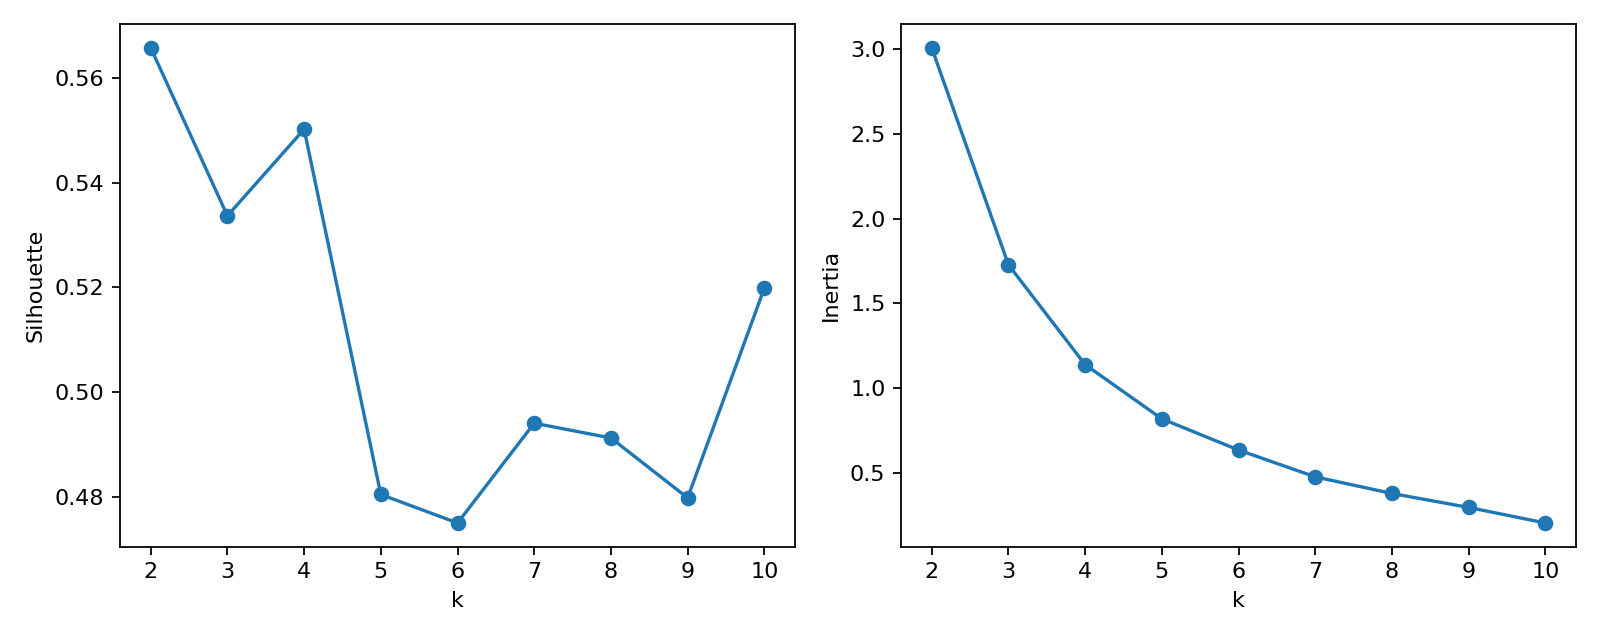

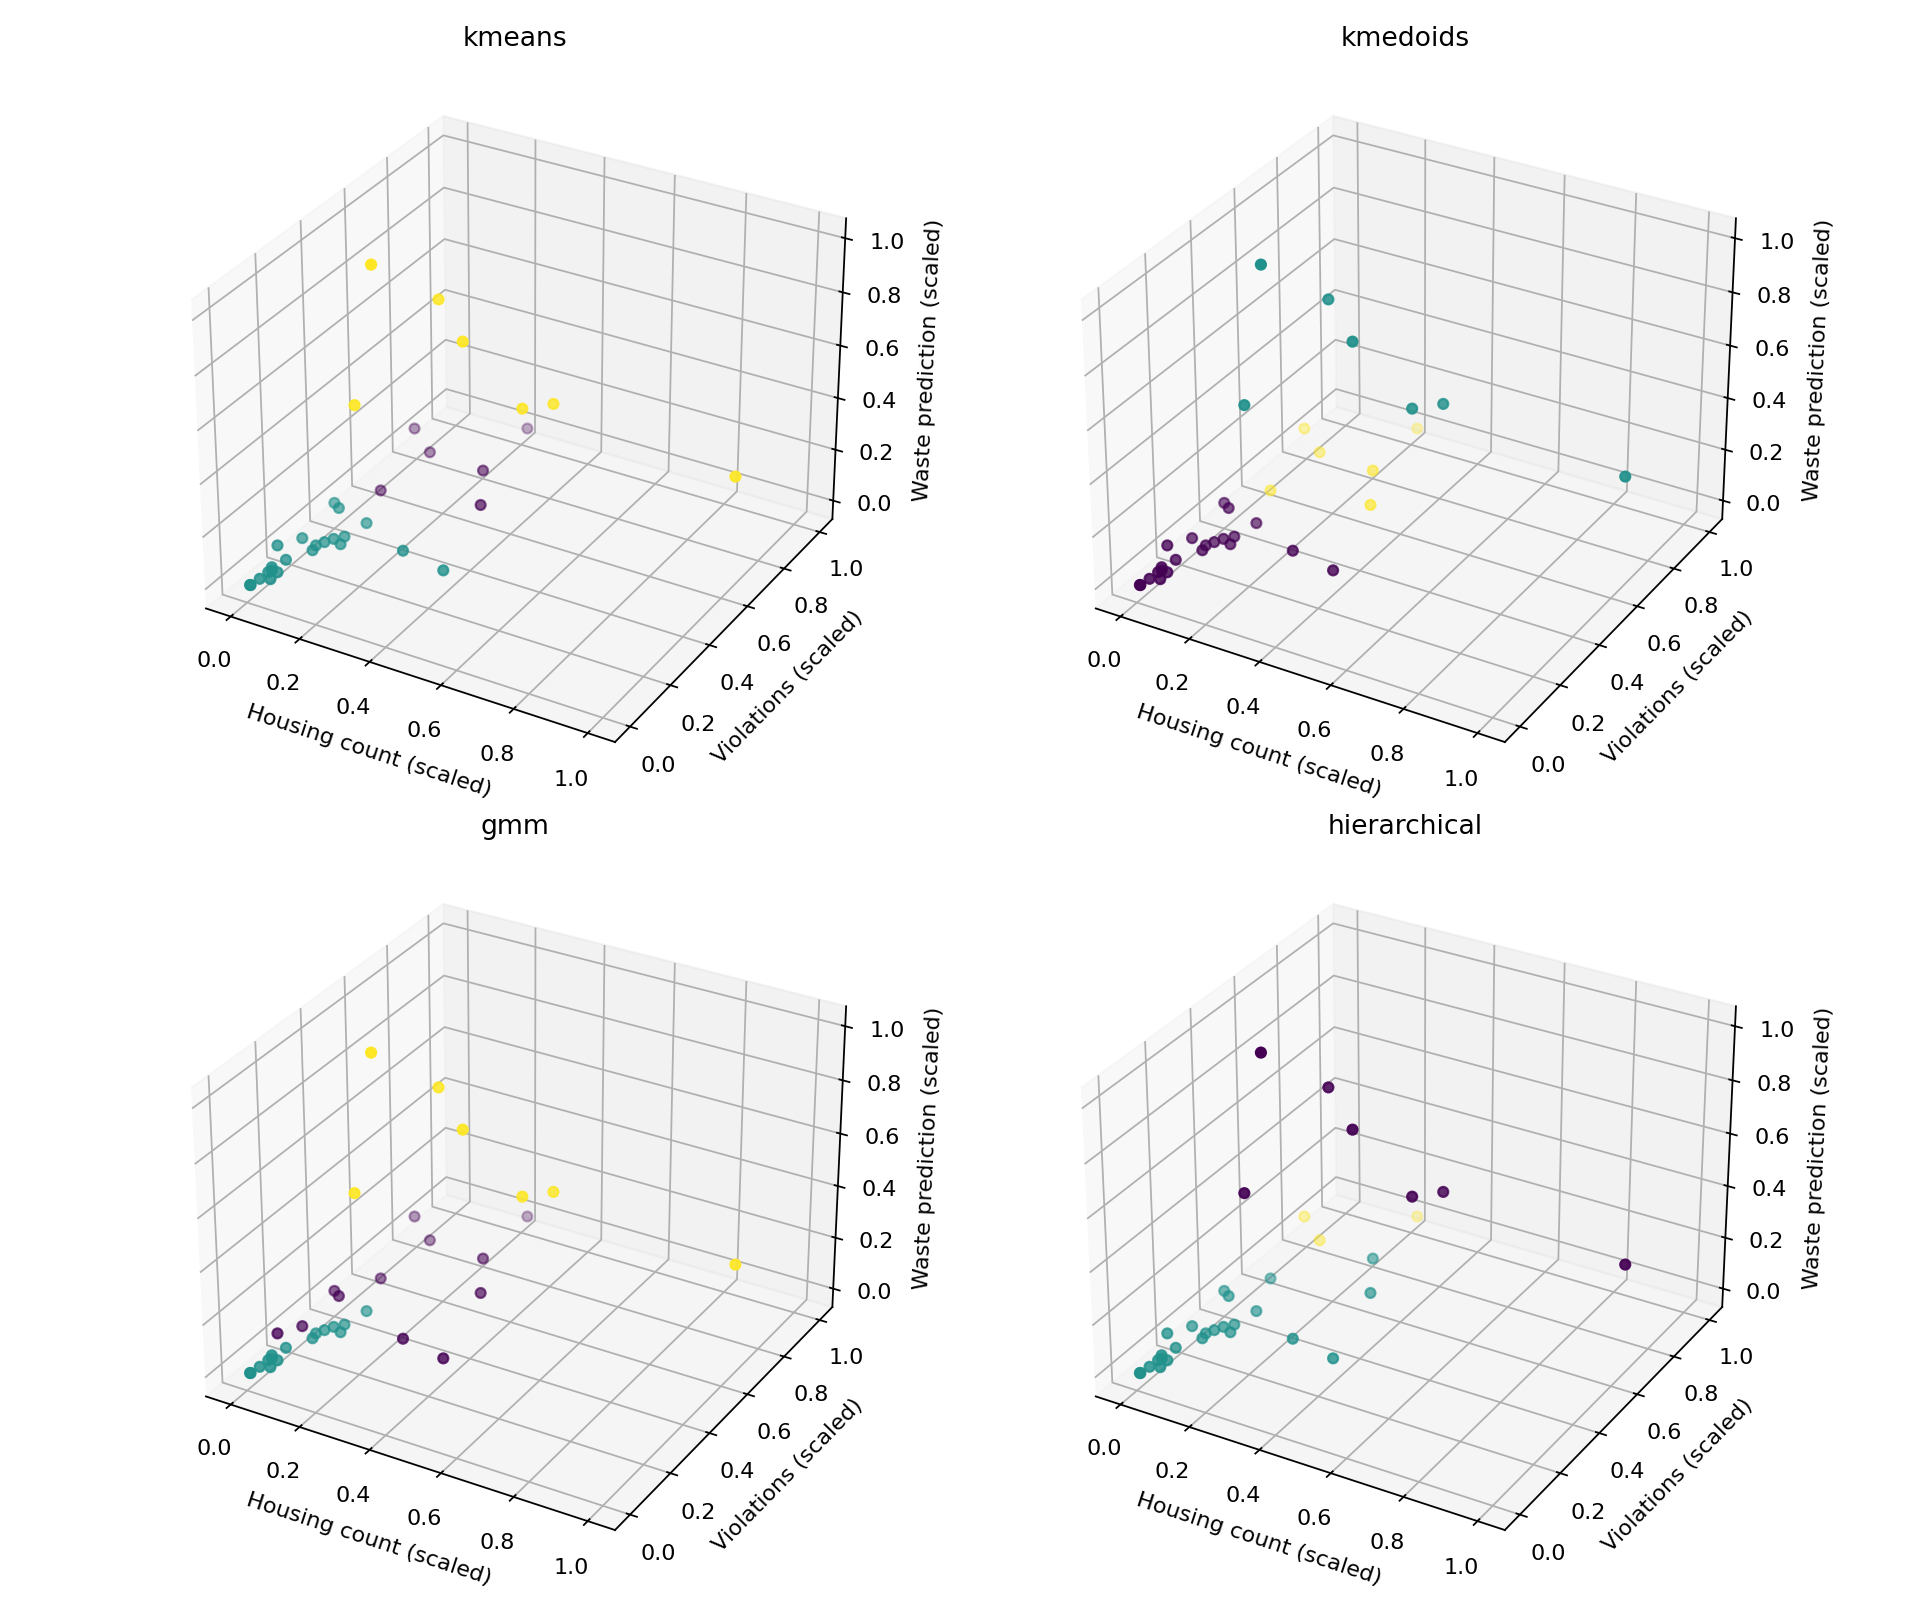

,행정동,인구수,세대수,원룸 및 주택 밀집,쓰레기 민원 빈도,연간 쓰레기 배출량 예측 값,전체 인구 대비 지역 인구 비율,kmeans_cluster,kmedoids_cluster,gmm_cluster,hierarchical_cluster,priority_score
0,효자5동,36079,18556,1410,60,11904.034,0.056508,2,1,2,0,0.670336
1,서신동,38869,17539,745,55,13698.702,0.060878,2,1,2,0,0.534654
2,혁신동,35931,13029,348,49,18328.905,0.056276,2,1,2,0,0.526754
3,인후3동,30137,14449,502,43,17324.749,0.047202,2,1,2,0,0.516060
4,송천1동,64691,24347,214,36,20953.023,0.101321,2,1,2,0,0.506374
5,효자4동,38595,16731,688,48,13993.824,0.060449,2,1,2,0,0.500625
6,평화2동,43236,18596,229,27,14707.287,0.067718,2,1,2,0,0.325620


새 우선순위 대상: 효자5동


In [11]:
summary = clustering(raw, scaled, features, X)
settings_path = result_path('dataset_settings.json')
if settings_path.exists():
    summary.update(json.loads(settings_path.read_text(encoding='utf-8')))
summary['outliers_removed'] = REMOVE_OUTLIERS
result_path('run_summary.json').write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding='utf-8')
display(Image(filename=str(result_path('cluster_k_diagnostics.png'))))
display(Image(filename=str(result_path('cluster_comparison.png'))))
display(pd.read_csv(result_path('selected_cluster_priority.csv')))
print('새 우선순위 대상:', summary['top_dong'])